In [14]:
import sys
if "vision_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

环境配置正常


In [15]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import cv2

print("opencv:", cv2.__version__)
print("numpy:", np.__version__)

opencv: 4.13.0
numpy: 2.2.5


<font color = #000000 >

## 4. 图像形态学操作
</font>


In [16]:
picture = '../Pictures/'
# 定义图像展示函数
def img_show(img):
    if img is None:
        print("图像读取失败")
    else:
        # 图像展示
        cv2.imshow("image", img)    # 首先需要确定图像存在才能打开
        print(img.shape)
        cv2.waitKey(0)  # 等待时间,0对应无限等待,知道按下任意按键
        cv2.destroyAllWindows() 

<font color = #000000>

### 4-1 腐蚀操作
</font>

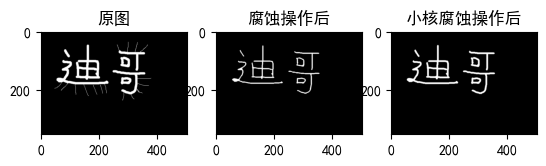

In [29]:
# 1. 读取图像
img = cv2.imread(picture + 'dige.png')

# 2. 腐蚀操作
kernel   = np.ones((5,5)  , np.uint8)   # 选择卷积核腐蚀就是基于一个点，看身边(核的大小)其他点的状况(腐蚀)
kernel2  = np.ones((3,3) , np.uint8)   # 这里腐蚀范围小一些
erosion  = cv2.erode(img,kernel ,iterations = 1)  # iterations: 腐蚀次数
erosion2 = cv2.erode(img,kernel2,iterations = 1)  # iterations: 腐蚀次数

# 3. 对比展示
plt.subplot(2, 3, 1) , plt.imshow(img,'gray') , plt.title('原图')
plt.subplot(2, 3, 2) , plt.imshow(erosion) , plt.title('腐蚀操作后')
plt.subplot(2, 3, 3) , plt.imshow(erosion2) , plt.title('小核腐蚀操作后')

plt.show()


<font color = #000000>

### 4-2 膨胀操作
</font>

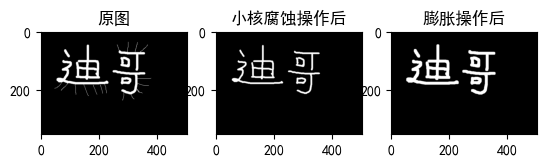

In [ ]:
# 1. 读取图像
img = cv2.imread(picture + 'dige.png')

# 2. 膨胀操作
kernel = np.ones((3,3),np.uint8) 
dige_erosion = cv2.dilate(erosion2,kernel,iterations = 2)    # 基于上次腐蚀得到的图像进行膨胀

# 3. 对比展示
plt.subplot(2, 3, 1) , plt.imshow(img,'gray') , plt.title('原图')
plt.subplot(2, 3, 2) , plt.imshow(erosion2) , plt.title('小核腐蚀操作后')
plt.subplot(2, 3, 3) , plt.imshow(dige_erosion) , plt.title('膨胀操作后')

plt.show()

(<Axes: title={'center': '膨胀:3次'}>,
 Text(0.5, 1.0, '膨胀:3次'))

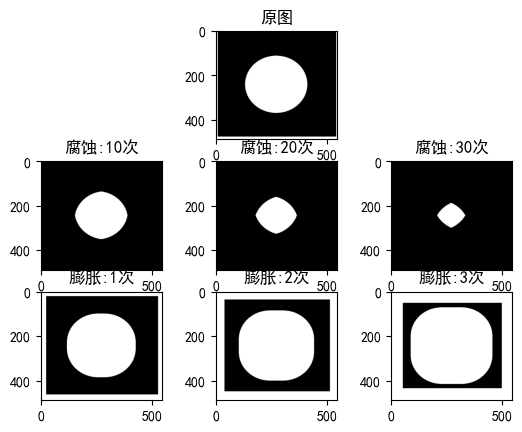

In [ ]:
# 膨胀-例2
# 1. 读图
pie = cv2.imread(picture + 'pie.png')

# 2. 腐蚀操作：核:(5,5) 次数:10*n
kernel = np.ones((5,5) , np.uint8)
erosion_1 = cv2.erode(pie,kernel,iterations = 10)
erosion_2 = cv2.erode(pie,kernel,iterations = 20)
erosion_3 = cv2.erode(pie,kernel,iterations = 30)

# 3. 膨胀操作：核:(30,30) 次数:1*n
kernel = np.ones((30,30) , np.uint8)
dilate_1 =  cv2.dilate(pie , kernel , iterations=1)
dilate_2 =  cv2.dilate(pie , kernel , iterations=2)
dilate_3 =  cv2.dilate(pie , kernel , iterations=3)

# 4. 对比展示
plt.subplot(3, 3, 2) , plt.imshow(pie,'gray') , plt.title('原图')

plt.subplot(3, 3, 4) , plt.imshow(erosion_1,'gray') , plt.title('腐蚀:10次')
plt.subplot(3, 3, 5) , plt.imshow(erosion_2,'gray') , plt.title('腐蚀:20次')
plt.subplot(3, 3, 6) , plt.imshow(erosion_3,'gray') , plt.title('腐蚀:30次')

plt.subplot(3, 3, 7) , plt.imshow(dilate_1 ,'gray') , plt.title('膨胀:1次')
plt.subplot(3, 3, 8) , plt.imshow(dilate_2 ,'gray') , plt.title('膨胀:2次')
plt.subplot(3, 3, 9) , plt.imshow(dilate_3 ,'gray') , plt.title('膨胀:3次')




<font color = #000000>

### 4-3 开运算与闭运算
+ 开运算: 先腐蚀再膨胀 `像“用小刷子把小亮点刷掉，然后恢复大物体形状”  去除小白点（小噪声）`
+ 闭运算: 先膨胀再腐蚀 `像“先把亮区域撑大，把小洞填满，然后再收回来”  填充小黑洞（小凹陷）`
</font>

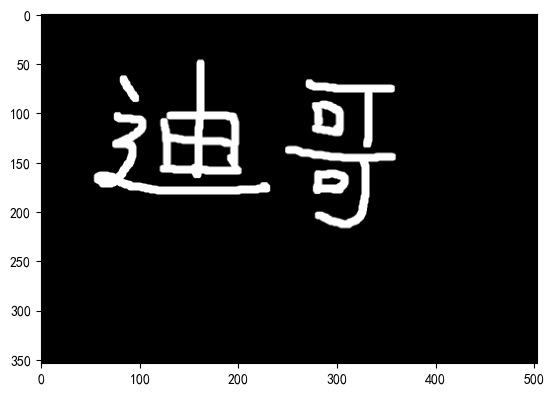

In [ ]:
# 开运算:先腐蚀再膨胀
img = cv2.imread(picture + 'dige.png')

kernel = np.ones((5,5) , np.uint8)

opening = cv2.morphologyEx(img , cv2.MORPH_OPEN , kernel) 

plt.imshow(opening)

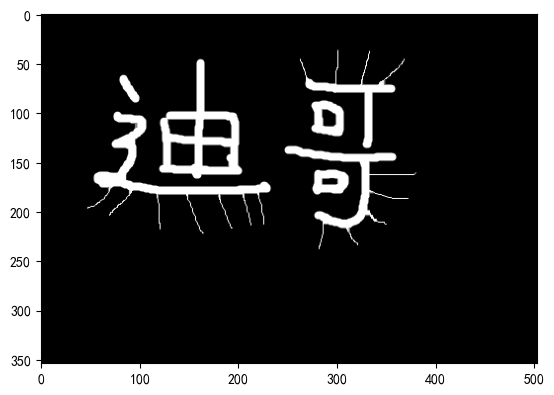

In [57]:
# 闭运算:先膨胀再腐蚀
img = cv2.imread(picture + 'dige.png')

kernel = np.ones((5,5) , np.uint8)

closing = cv2.morphologyEx(img , cv2.MORPH_CLOSE , kernel) 

plt.imshow(closing)

<font color = #000000>

### 4-4 梯度运算
* 梯度 = 膨胀 - 腐蚀

</font>

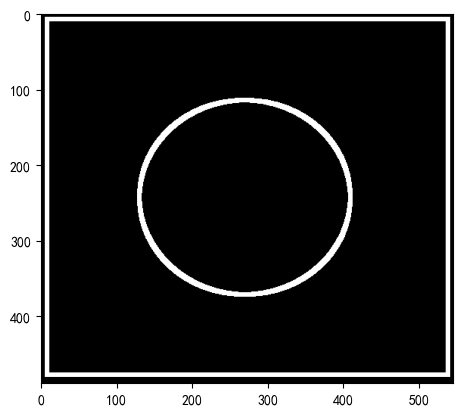

In [ ]:
pie = cv2.imread(picture + 'pie.png')
kernel = np.ones((7,7),np.uint8) 
# 得到梯度:先膨胀再腐蚀
gradient = cv2.morphologyEx(pie , cv2.MORPH_GRADIENT , kernel)
plt.imshow(gradient)

<font color = #000000>

### 4-5 礼帽和黑帽
+ 礼帽 = 原始输入 - 开运算结果(先腐蚀再膨胀) -> 开运算得到不带毛刺版本,所以礼帽得到仅毛刺 `提取 小亮点、凸起、局部高光`
    + 礼帽 → 找 “亮的小东西”
+ 黑帽 = 闭运算(先膨胀再腐蚀) - 原始输入     -> 闭运算得到刺更多的版本,刺-刺得到少数轮廓点 `提取 小暗点、凹陷、局部阴影`
    + 黑帽 → 找“暗的小东西”

</font>

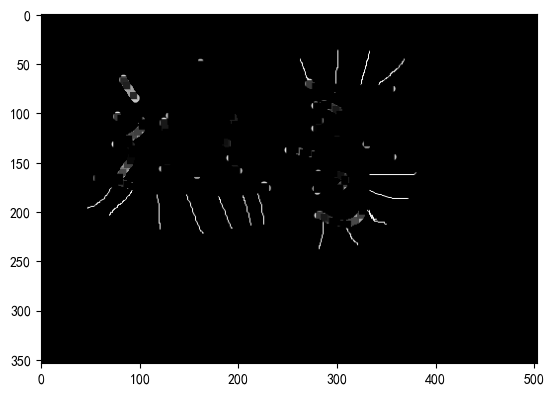

In [64]:
# 1. 礼帽
img = cv2.imread(picture + "dige.png")
tophat = cv2.morphologyEx(img , cv2.MORPH_TOPHAT , kernel)
plt.imshow(tophat)

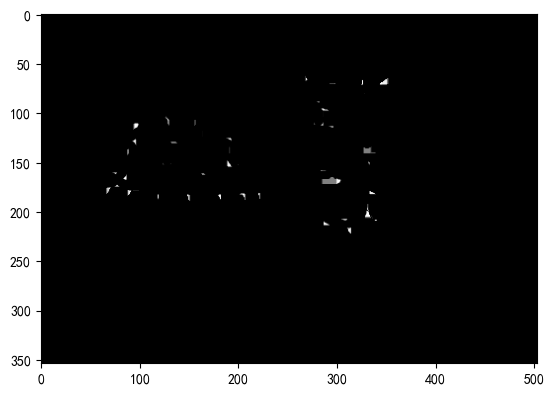

In [65]:
# 2. 黑帽
img = cv2.imread(picture + "dige.png")
blackhat = cv2.morphologyEx(img , cv2.MORPH_BLACKHAT , kernel)
plt.imshow(blackhat)

<font color = #000000>

### 参考格式
</font>